# SDATIP-Fast Example

This notebook demonstrates how to use `SDATIP` to determine the arrival time and initial polarity of seismic waveforms.

In [21]:
import numpy as np
import os
import obspy
import matplotlib.pyplot as plt
import sdatip

print(f"SDATIP version: {sdatip.__version__}")

SDATIP version: 1.0.1


## 1. Process Real Seismic Data from SAC File

In [16]:
sac_file = "./Hinettest/N.AAKH_onset.SAC"
stream = obspy.read(sac_file)
trace = stream[0]

print(f"Station: {trace.stats.station}")
print(f"Sampling rate: {trace.stats.sampling_rate} Hz")
print(f"Duration: {len(trace.data) / trace.stats.sampling_rate:.2f} seconds")

Station: N.AAKH
Sampling rate: 100.0 Hz
Duration: 10.01 seconds


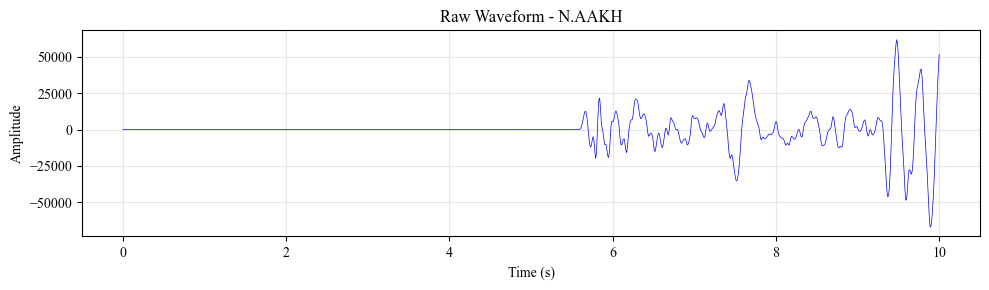

In [12]:
time_axis = np.arange(len(trace.data)) * trace.stats.delta

# Make sure Matplotlib uses Times New Roman which we just installed in WSL
plt.rcParams['font.family'] = 'Times New Roman'
# if Times New Roman is not available, you can use a similar serif font like 'serif' or 'DejaVu Serif'
# plt.rcParams['font.family'] = 'DejaVu Serif'

plt.figure(figsize=(10, 3))
plt.plot(time_axis, trace.data, 'b-', linewidth=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'Raw Waveform - {trace.stats.station}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Process with SDATIP 

We use `process_waveform` to get the arrival time and polarity.

In [24]:
output_dir = "./output_example/"
os.makedirs(output_dir, exist_ok=True)

data = trace.data.astype(np.float32)

result = sdatip.process_waveform(
    name=trace.stats.station,
    data=data,
    output_dir=output_dir,
    plot_enabled=False
)

for res in result['results']:
    print(f"Solution {res['solution_id']}:")
    print(f"  Arrival time: {res['arrival_time']:.3f} s")
    print(f"  Polarity up: {res['polarity_up']:.3f}")



calculating ampprob
Solution 0:
  Arrival time: 5.593 s
  Polarity up: 1.000
Solution 1:
  Arrival time: 9.334 s
  Polarity up: 0.000


## 3. Step-by-Step Processing (Advanced)

In [25]:
wf = sdatip.Waveform("N.AAKH")
wf.importdata(data, delta=trace.stats.delta)
wf.analyzedata()
wf.rmmean()
wf.interpolate(1)
wf.denseunique()
wf.denselong(hvcoefficient=2.5, mininsertco=200)
wf.extremearr()
wf.densebin()
print("Waveform object initialized and pre-processed.")

Waveform object initialized and pre-processed.


In [26]:
state = wf.constructstate()
timeprobs, num_solutions = state.markovmatrix()

print(f"Number of solutions found: {num_solutions}")

ampprob = state.ampprobcalculate()

for solution_id in range(num_solutions):
    state.estimation(solution_id)
    print(f"\nSolution {solution_id}:")
    print(f"  Estimated Arrival: {state.arrivalestimate:.3f} s")
    print(f"  Polarity Up Prob: {state.polarityup:.3f}")

Number of solutions found: 2


calculating ampprob

Solution 0:
  Estimated Arrival: 9.334 s
  Polarity Up Prob: 0.000

Solution 1:
  Estimated Arrival: 5.604 s
  Polarity Up Prob: 1.000


## 4. Plotting the Results

SDATIP provides built-in plotting functions. Setting `plot_enabled=True` in `process_waveform` or calling the `sdatip.plotting` module directly will generate visualization PDFs in the output directory.

In [29]:
# You can let process_waveform automatically generate plots by setting `plot_enabled=True`
# It will generate the exact same figures directly and save them to the specified output folder

import sdatip
import numpy as np
import os

auto_plot_dir = "./output_auto_plot/"
os.makedirs(auto_plot_dir, exist_ok=True)

print("Processing and generating plots...")
result_with_plots = sdatip.process_waveform(
    name=f"{trace.stats.station}_auto_plot",
    data=data,
    output_dir=auto_plot_dir,
    plot_enabled=True
)

import glob
print(f"Automatic plots generated in {auto_plot_dir}:")
print(glob.glob(f"{auto_plot_dir}/*.pdf"))

Processing and generating plots...


calculating ampprob


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Automatic plots generated in ./output_auto_plot/:
['./output_auto_plot/N.AAKH_auto_plot_0.pdf', './output_auto_plot/N.AAKH_auto_plot_1.pdf']


In [27]:
from sdatip.plotting import plot_result, plot_result_graduate

# Generate plot for the first solution (solution_id = 0)
solution_id = 0

# Note: These funcs will create pdf/eps files in output_dir
plot_result(wf, state, solution_id, trace.stats.station, output_dir)
plot_result_graduate(wf, state, solution_id, trace.stats.station, output_dir)

print(f"Plots saved to {output_dir}")

import glob
from pprint import pprint
print("\nGenerated PDF files:")
pprint(glob.glob(f"{output_dir}/*.pdf"))

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Plots saved to ./output_example/

Generated PDF files:
['./output_example/N.AAKH_0.pdf']


## 5. Batch Processing Multiple Waveforms

Use `process_batch` to process an entire folder of waveforms using multi-processing. This is especially useful for processing massive seismic datasets.

In [28]:
import time

batch_output_dir = "./output_batch/"

print("Starting batch processing...")
start_time = time.time()

# Run the batch processor
# Note: Using num_workers=1 here due to a typical multiprocessing limitation in some Python environments.
# To use multi-core, you might need to run it as a standalone script or adjust multiprocessing context.
batch_results = sdatip.process_batch(
    input_dir="./Hinettest/", 
    output_dir=batch_output_dir,
    num_workers=1,           # Set to 1 for single-threaded processing in notebooks
    plot_enabled=False,      # Set to True to generate plots for every waveform
    pattern="*onset.SAC"     # Matches all SAC files in the Hinettest folder
)

print(f"\nBatch processing completed in {time.time() - start_time:.2f} seconds.")
print(f"Successfully processed {len(batch_results)} files.")

# Show a quick summary of the first result
if batch_results:
    first_res = batch_results[0]['results'][0]
    print(f"\nExample result from batch processing:")
    print(f"  Arrival time: {first_res['arrival_time']:.3f} s")
    print(f"  Polarity up: {first_res['polarity_up']:.3f}")

Starting batch processing...
Found 5 traces to process.
Processing in single-threaded mode...


 20%|██        | 1/5 [00:26<01:46, 26.59s/it]



calculating ampprob


 40%|████      | 2/5 [00:52<01:19, 26.42s/it]



calculating ampprob


...



calculating ampprob


 80%|████████  | 4/5 [02:49<00:47, 47.01s/it]



calculating ampprob


100%|██████████| 5/5 [05:44<00:00, 68.95s/it]



calculating ampprob
Successfully processed 5 traces.

Batch processing completed in 345.40 seconds.
Successfully processed 5 files.

Example result from batch processing:
  Arrival time: 5.414 s
  Polarity up: 0.000
